#  Projet Machine Learning

### Your names
Your link to the github page of the project

Link to open the notebook in Google colab

**Insérer une table des matières**

## 1) Sujet

Challenge Data from College de France ou Le Lab Banque de France : https://challengedata.ens.fr/challenges/97

### 1.1) Contexte

L'objectif du challenge est de modéliser les variations journalières du prix des contrats futures d'électricité pour la France et l'Allemagne à partir de variables explicatives météorologiques, énergétiques et commerciales.

Il s'agit d'un problème de régression supervisée dans lequel la variable cible correspond à la variation du prix de l'électricité à court terme (24h). L'objectif principal est d'expliquer les variations relatives du prix plutôt qu'en estimer la valeur. Cela est reflété par la métrique de corrélation de Spearman qui mesure la capacité du modèle à correctement ordonner les observations. Les données incluent notamment des variations journalières du prix des matières premières (Gaz, Charbon et futures sur les émissions carbone), des mesures météorologiques (température, pluie et vent), des mesures de productions (gaz naturel, charbon, hydrolique, nucléaire, photovoltaïque, éolienne, lignite) ainsi que des mesures d'utilisation électrique (consommation, exports, échanges entre la France et l'Allemagne).

Contexte du marché de l'électricité : 
Le marché de l'électricité est un marché où l'actif est physique et non stockable. Son prix est fixé par le coût marginal de la dernière unité de production (merit order). La France et l'Allemagne au dela que leur proximité et de leur frontière en commun, importent et exportent de l'électricité entre leur deux pays. En effet, ayant des mix énergétiques bien différents (plutôt nucléaire pour la France et renouvelable pour l'Allemagne), des arbitrages peuvent avoir lieu entre ces deux pays.

Lors d'évènement météorologique où le vent et le soleil sont absents, l'Allemagne doit allumer leurs centrales à charbon. Afin de palier à cette méthode de production d'électricité qui coûte cher, l'Allemagne peut acheter de l'électricité produite par les centrales française. Nous voyons donc tout l'intérêt d'étudier ces deux pays, lié dans la production d'électricité.

### 1.2) Description des données

Index des données

**Variables explicatives**

**Variable cible**


### 1.3) Description du benchmark

## 2) Problématique 

## 3) Préparation des données

### 3.1) Importations des bibliothèques

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

from pathlib import Path
import os

from scipy.stats import spearmanr
from sklearn.metrics import *

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor


### 3.2) Importation des données

##### Importation de nos tables en dataframe pandas

In [43]:
# data set entrainement
possible_paths = [
    Path("/Users/yves-mariesaliou/Documents/Cours/M2 IEF 272/MACHINE LEARNING/PROJET QRT ELEC"),
    Path("/Users/liessenathan/Desktop/M2/ML/PROJET-QRT-ELEC")
]
path = next((p for p in possible_paths if p.exists()), None)
path = str(path)

x_train = pd.read_csv(os.path.join(path, "X_train_NHkHMNU.csv")).sort_values(by=["COUNTRY", "DAY_ID"])
y_train = pd.read_csv(os.path.join(path, "y_train_ZAN5mwg.csv"))

# ensemble de test
x_test = pd.read_csv(os.path.join(path, "X_test_final.csv"))
y_test = pd.read_csv(os.path.join(path, "y_test_random_final.csv"))

##### Vérification des tailles des fichiers

In [44]:
display(x_train.dtypes)
display(x_train.shape)

ID                    int64
DAY_ID                int64
COUNTRY              object
DE_CONSUMPTION      float64
FR_CONSUMPTION      float64
DE_FR_EXCHANGE      float64
FR_DE_EXCHANGE      float64
DE_NET_EXPORT       float64
FR_NET_EXPORT       float64
DE_NET_IMPORT       float64
FR_NET_IMPORT       float64
DE_GAS              float64
FR_GAS              float64
DE_COAL             float64
FR_COAL             float64
DE_HYDRO            float64
FR_HYDRO            float64
DE_NUCLEAR          float64
FR_NUCLEAR          float64
DE_SOLAR            float64
FR_SOLAR            float64
DE_WINDPOW          float64
FR_WINDPOW          float64
DE_LIGNITE          float64
DE_RESIDUAL_LOAD    float64
FR_RESIDUAL_LOAD    float64
DE_RAIN             float64
FR_RAIN             float64
DE_WIND             float64
FR_WIND             float64
DE_TEMP             float64
FR_TEMP             float64
GAS_RET             float64
COAL_RET            float64
CARBON_RET          float64
dtype: object

(1494, 35)

### 3.3) Exploration des données 

#### Informations sur notre dataset + interprétation

In [45]:
# Y a-t-il chevauchement temporel entre train et test ?
print("Train DAY_ID :", x_train['DAY_ID'].min(), "→", x_train['DAY_ID'].max())
print("Test  DAY_ID :", x_test['DAY_ID'].min(), "→", x_test['DAY_ID'].max())
print("Jours communs :", set(x_train['DAY_ID']) & set(x_test['DAY_ID']))

# Répartition des pays
print("\nTrain countries :", x_train['COUNTRY'].value_counts().to_dict())
print("Test  countries :", x_test['COUNTRY'].value_counts().to_dict())

# Combien d'observations par (DAY_ID, COUNTRY) ?
print("\nDoublons (DAY_ID, COUNTRY) train :", 
      x_train.duplicated(subset=['DAY_ID', 'COUNTRY']).sum())

Train DAY_ID : 0 → 1215
Test  DAY_ID : 4 → 1214
Jours communs : set()

Train countries : {'FR': 851, 'DE': 643}
Test  countries : {'FR': 365, 'DE': 289}

Doublons (DAY_ID, COUNTRY) train : 0


Donc les jours sont disjoints mais entrelacés : ce n'est pas un split temporel pur (passé→futur), c'est un split aléatoire au niveau du jour. Les jours ont été tirés au hasard et répartis entre train et test, sur la même période globale.

In [46]:
x_train[[col for col in x_train.columns if "ID" not in col]].describe()
# on a donc 30 variables explicatives disponibles pour notre Y

,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,FR_NET_IMPORT,DE_GAS,FR_GAS,...,DE_LIGNITE,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET
count,1494.000000,1494.000000,1469.000000,1469.000000,1370.000000,1424.000000,1370.000000,1424.000000,1494.000000,1494.000000,...,1494.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1494.000000,1494.000000,1494.000000
mean,0.427442,-0.020032,-0.145508,0.145508,-0.256332,-0.072643,0.256332,0.072643,0.780699,0.395019,...,-0.298856,-0.037831,0.019357,0.109480,0.123099,0.009451,0.008404,0.058126,0.061724,0.080510
std,0.673412,0.918995,0.970226,0.970226,0.957443,1.075830,0.957443,1.075830,0.850190,0.906500,...,0.851339,0.984233,1.051781,1.056243,1.054692,0.972394,1.003356,1.097768,1.033853,1.098624
min,-2.265563,-1.462350,-2.856874,-2.634831,-2.464849,-2.825331,-2.279619,-1.951516,-1.117260,-1.317350,...,-2.879041,-2.128531,-1.726420,-1.880419,-1.895319,-4.549638,-5.787097,-5.349463,-5.706442,-4.281790
25%,-0.037421,-0.716771,-0.875213,-0.638867,-0.977214,-0.851500,-0.452252,-0.794843,0.134947,-0.205078,...,-0.787239,-0.642117,-0.503927,-0.652135,-0.672614,-0.618259,-0.647948,-0.624238,-0.458038,-0.522968
50%,0.357061,-0.394166,-0.164287,0.164287,-0.306899,0.099455,0.306899,-0.099455,0.740006,0.256780,...,-0.188300,-0.274901,-0.228147,-0.261571,-0.229031,-0.026306,-0.020889,0.008493,0.063312,0.054056
75%,0.922057,0.650533,0.638867,0.875213,0.452252,0.794843,0.977214,0.851500,1.399461,1.090646,...,0.273510,0.335237,0.154351,0.635050,0.824781,0.651832,0.699131,0.676415,0.641446,0.599094
max,2.033851,3.300640,2.634831,2.856874,2.279619,1.951516,2.464849,2.825331,3.118082,2.372570,...,1.586885,7.756118,9.473201,5.085624,4.965028,2.858758,2.817239,5.674778,3.746576,5.471818


#### Informations sur nos features + interprétation

<Axes: title={'center': 'Return Prix Electricité DE'}, xlabel='DAY_ID'>

<Axes: title={'center': 'Return Prix Electricité FR'}, xlabel='DAY_ID'>

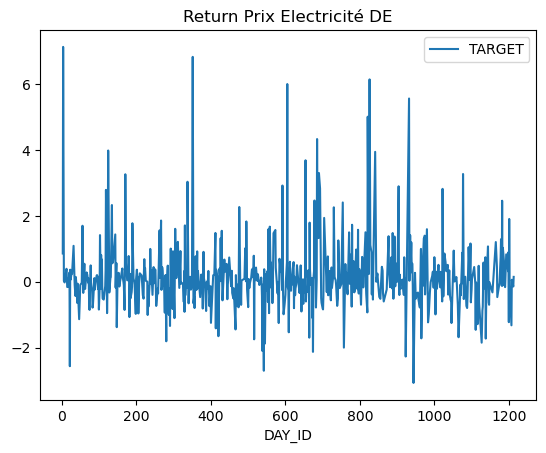

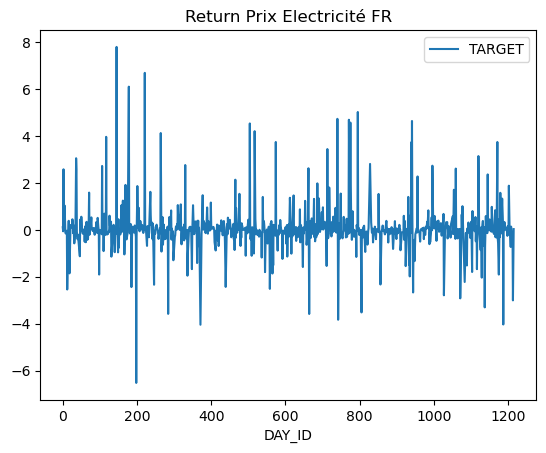

In [47]:
for country in x_train.COUNTRY.unique():
    display(x_train.query(f"COUNTRY == '{country}'")
            .merge(y_train).sort_values(by="DAY_ID")
            .plot(x="DAY_ID", y="TARGET", title=f"Return Prix Electricité {country}"))

#### Corrélation entre les features et la cible (V de Cramer ou test Chi-deux ou kruskall-wallis selon si les features et la cible sont continues ou catégorielles)

## 4) Traitement et création de nouvelles features

### 4.2) Traitement des valeurs manquantes (Imputation)

### 4.2.b) Flux Analysis

Logiquement on a 
- DE_FR_EXCHANGE = - FR_DE_EXCHANGE
- DE_NET_EXPORT = - DE_NET_IMPORT
- FR_NET_EXPORT = - FR_NET_IMPORT

In [48]:
flow_pairs = [
    ("DE_FR_EXCHANGE", "FR_DE_EXCHANGE"),
    ("DE_NET_EXPORT", "DE_NET_IMPORT"),
    ("FR_NET_EXPORT", "FR_NET_IMPORT"),
    ]


x_train = x_train.sort_values("DAY_ID")

flux_cols = [c for pair in flow_pairs for c in pair]

display(x_train[["DAY_ID", "COUNTRY"] + flux_cols])
display(x_train.isna().sum().sort_values(ascending=False))

,DAY_ID,COUNTRY,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,DE_NET_IMPORT,FR_NET_EXPORT,FR_NET_IMPORT
742,0,FR,-0.079296,0.079296,NaN,NaN,0.650577,-0.650577
1211,1,FR,0.331356,-0.331356,0.405549,-0.405549,0.778627,-0.778627
1408,2,FR,-1.102015,1.102015,-1.080403,1.080403,0.256736,-0.256736
1468,2,DE,-1.102015,1.102015,-1.080403,1.080403,0.256736,-0.256736
680,3,DE,-1.051716,1.051716,-1.881881,1.881881,-0.612133,0.612133
...,...,...,...,...,...,...,...,...
986,1212,DE,-0.270515,0.270515,-0.137917,0.137917,-0.789824,0.789824
1007,1212,FR,-0.270515,0.270515,-0.137917,0.137917,-0.789824,0.789824
1465,1213,DE,-0.456126,0.456126,0.333142,-0.333142,-0.069222,0.069222
873,1213,FR,-0.456126,0.456126,0.333142,-0.333142,-0.069222,0.069222


DE_NET_EXPORT       124
DE_NET_IMPORT       124
DE_RAIN              94
FR_TEMP              94
DE_TEMP              94
FR_WIND              94
DE_WIND              94
FR_RAIN              94
FR_NET_IMPORT        70
FR_NET_EXPORT        70
DE_FR_EXCHANGE       25
FR_DE_EXCHANGE       25
DE_LIGNITE            0
DE_RESIDUAL_LOAD      0
FR_RESIDUAL_LOAD      0
ID                    0
DE_WINDPOW            0
GAS_RET               0
COAL_RET              0
FR_WINDPOW            0
DE_NUCLEAR            0
FR_SOLAR              0
DE_SOLAR              0
FR_NUCLEAR            0
DAY_ID                0
FR_HYDRO              0
DE_HYDRO              0
FR_COAL               0
DE_COAL               0
FR_GAS                0
DE_GAS                0
FR_CONSUMPTION        0
DE_CONSUMPTION        0
COUNTRY               0
CARBON_RET            0
dtype: int64

### 4.2.b) Completion

### Median == Approche finale

In [49]:
def median_completion(df, columns_to_fill) -> pd.DataFrame:
    """
    Arg : df à compléter
    """
    x_median = df.copy()

    for col in columns_to_fill:
        x_median[col] = x_median[col].fillna(
            x_median.groupby("COUNTRY")[col].transform("median")
        )
    
    return x_median

colums_to_fill_train = x_train.isna().sum()[x_train.isna().sum() > 0].index
colums_to_fill_test = x_test.isna().sum()[x_test.isna().sum() > 0].index

# apply completion to both test and train
x_train_median, x_test_median = median_completion(x_train, colums_to_fill_train), median_completion(x_test, colums_to_fill_test)

### 4.1) Ajout de nouvelles features et création TRAIN et TEST

Le prix de l'électricité spot (et donc sa variation journalière, qui est ta cible) est déterminé par le coût marginal de production : à chaque instant, on empile les centrales par ordre de coût croissant, et le prix est fixé par la dernière centrale appelée pour satisfaire la demande. Cette logique s'appelle le merit order.

Conséquences directes :

* Plus la demande résiduelle (consommation moins renouvelables, qui sont quasi-gratuites) est élevée, * plus on appelle des centrales chères → prix élevé.
* Plus le coût des combustibles fossiles (gaz, charbon) et du carbone est élevé, plus les centrales marginales coûtent cher → prix élevé.
* Les échanges transfrontaliers redistribuent ces effets entre marchés couplés.

In [50]:
x_train_median.columns

Index(['ID', 'DAY_ID', 'COUNTRY', 'DE_CONSUMPTION', 'FR_CONSUMPTION',
       'DE_FR_EXCHANGE', 'FR_DE_EXCHANGE', 'DE_NET_EXPORT', 'FR_NET_EXPORT',
       'DE_NET_IMPORT', 'FR_NET_IMPORT', 'DE_GAS', 'FR_GAS', 'DE_COAL',
       'FR_COAL', 'DE_HYDRO', 'FR_HYDRO', 'DE_NUCLEAR', 'FR_NUCLEAR',
       'DE_SOLAR', 'FR_SOLAR', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_LIGNITE',
       'DE_RESIDUAL_LOAD', 'FR_RESIDUAL_LOAD', 'DE_RAIN', 'FR_RAIN', 'DE_WIND',
       'FR_WIND', 'DE_TEMP', 'FR_TEMP', 'GAS_RET', 'COAL_RET', 'CARBON_RET'],
      dtype='object')

In [51]:
def metric_train(y_true, y_pred):
    return spearmanr(y_pred, y_true).correlation

# cible alignée sur ID
x_train_median.sort_values(["COUNTRY", "DAY_ID"], inplace=True)
y_train_clean = y_train.set_index("ID").loc[x_train_median["ID"], "TARGET"]


#### Clippage des rendements aux quantiles

In [52]:
# Clipping des rendements aux quantiles 1% / 99% (calcul sur train, appliqué aux deux)
ret_cols = ['GAS_RET', 'COAL_RET', 'CARBON_RET']
lower = x_train_median[ret_cols].quantile(0.01)
upper = x_train_median[ret_cols].quantile(0.99)

x_train_median[ret_cols] = x_train_median[ret_cols].clip(lower=lower, upper=upper, axis=1)
x_test_median[ret_cols]  = x_test_median[ret_cols].clip(lower=lower, upper=upper, axis=1)

In [53]:
def add_physical_features(df):
    df = df.copy()

    # ÉCHANGES TRANSFRONTALIERS NETS
    # flux net DE→FR (positif = DE exporte vers FR)
    df['NET_FLOW_DE_TO_FR'] = df['DE_FR_EXCHANGE'] - df['FR_DE_EXCHANGE']
    df['DE_NET_BALANCE'] = df['DE_NET_EXPORT'] - df['DE_NET_IMPORT']
    df['FR_NET_BALANCE'] = df['FR_NET_EXPORT'] - df['FR_NET_IMPORT']


    # COUT MARGINAL DE PRODUCTION (Merit Order)
    # cout effectif des centrales gaz (cout gaz + taxe carbone)
    df['GAS_CARBON_COST'] = df['GAS_RET'] + df['CARBON_RET']
    # cout effectif des centrales charbon
    df["COAL_CARBON_COST"] = df['COAL_RET'] + df['CARBON_RET']
    # cout fossile (proxy du prix marginal)
    df["FOSSIL_COST_INDEX"] = 0.5 * df["GAS_CARBON_COST"] + 0.5 * df["COAL_CARBON_COST"]

    # DEMANDE RESIDUELLE + INTERACTIONS METEO × PRODUCTION
    for country in ["DE", "FR"]:
        renewable = df[f"{country}_SOLAR"] + df[f"{country}_WINDPOW"] + df[f"{country}_HYDRO"]
        consumption = df[f"{country}_CONSUMPTION"]

        # prod totale ENR
        df[f"{country}_RENEWABLE_PROD"] = renewable
        # taux de penetration ENR
        df[f"{country}_RENEWABLE_PENETRATION"] = renewable / consumption
        # ratio demande residuelle / consommation totale
        df[f"{country}_RESIDUAL_LOAD_RATIO"] = df[f"{country}_RESIDUAL_LOAD"] / consumption

        # prod ENR variable (vent + soleil)
        df[f"{country}_WIND_SOLAR_PROD"] = df[f"{country}_WINDPOW"] + df[f"{country}_SOLAR"]
        # temp × demande résiduelle
        df[f"{country}_TEMP_x_RESIDUAL"] = df[f"{country}_TEMP"] * df[f"{country}_RESIDUAL_LOAD"]
        # vent × production vent
        df[f"{country}_WIND_x_WINDPOW"] = df[f"{country}_WIND"] * df[f"{country}_WINDPOW"]
        # pluie × hydraulique
        df[f"{country}_RAIN_x_HYDRO"] = df[f"{country}_RAIN"] * df[f"{country}_HYDRO"]
        # cout gaz pondere par la production gaz du pays
        df[f"{country}_GAS_COST_x_PROD"] = df["GAS_RET"]  * df[f"{country}_GAS"]
        # cout charbon pondere par la production charbon du pays
        df[f"{country}_COAL_COST_x_PROD"] = df["COAL_RET"] * df[f"{country}_COAL"]


    # BESOIN THERMIQUE
    df["DE_THERMAL_NEED"] = df["DE_RESIDUAL_LOAD"] - df["DE_NUCLEAR"] - df["DE_LIGNITE"]
    df["FR_THERMAL_NEED"] = df["FR_RESIDUAL_LOAD"] - df["FR_NUCLEAR"]

    # FEATURES CROSS-PAYS (signal d'arbitrage DE ↔ FR)
    df["RESIDUAL_LOAD_DIFF"] = df["DE_RESIDUAL_LOAD"] - df["FR_RESIDUAL_LOAD"]
    df["RENEWABLE_DIFF"] = df["DE_RENEWABLE_PROD"] - df["FR_RENEWABLE_PROD"]
    df["TEMP_DIFF"] = df["DE_TEMP"] - df["FR_TEMP"]
    df["NUCLEAR_DIFF"] = df["DE_NUCLEAR"] - df["FR_NUCLEAR"]
    df["RENEWABLE_PENETRATION_DIFF"] = df["DE_RENEWABLE_PENETRATION"] - df["FR_RENEWABLE_PENETRATION"]

    # BALANCE COMMERCIALE ÉLECTRIQUE
    df['DE_TRADE_BALANCE'] = df['DE_NET_EXPORT'] - df['DE_NET_IMPORT']
    df['FR_TRADE_BALANCE'] = df['FR_NET_EXPORT'] - df['FR_NET_IMPORT']

    # ONE-HOT ENCODING DE COUNTRY
    df['COUNTRY_DE'] = (df['COUNTRY'] == 'DE').astype(int)
    df['COUNTRY_FR'] = (df['COUNTRY'] == 'FR').astype(int)
    df.drop(columns="COUNTRY", inplace=True)

    return df

x_train_median = add_physical_features(x_train_median)
x_test_median  = add_physical_features(x_test_median)

### 4.1) Normalisation des données

In [54]:
from sklearn.preprocessing import StandardScaler

index_cols = ["ID", "DAY_ID"]
do_not_normalize= index_cols + ["COUNTRY_FR", "COUNTRY_DE"]
cols_to_normalize = [c for c in x_train_median.columns if c not in do_not_normalize]

# scaler = StandardScaler()

# x_train_median[cols_to_normalize] = scaler.fit_transform(x_train_median[cols_to_normalize])
# x_test_median[cols_to_normalize]  = scaler.transform(x_test_median[cols_to_normalize])

# Transformation en rangs gaussiens (aligne les features avec la métrique Spearman)
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(output_distribution='normal', random_state=42)

# On applique la transfo sur les colonnes continues uniquement
x_train_median[cols_to_normalize] = qt.fit_transform(x_train_median[cols_to_normalize])
x_test_median[cols_to_normalize]  = qt.transform(x_test_median[cols_to_normalize])

### 4.) Sélection de variable : Spearman Corrélation + Permutation Importance

In [55]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import make_scorer
from scipy.stats import spearmanr
import numpy as np
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

# Scorer Spearman pour la cross validation
spearman_scorer = make_scorer(
    lambda y_true, y_pred: spearmanr(y_true, y_pred).correlation,
    greater_is_better=True
)

# GroupKFold sur DAY_ID : DE et FR d'un même jour restent dans le même fold
groups = x_train_median['DAY_ID'].values
gkf = GroupKFold(n_splits=5)

feature_cols = [c for c in x_train_median.columns if c not in index_cols]
X_cv = x_train_median.set_index("ID")[feature_cols]
y_cv = y_train_clean

# Baseline : score avec toutes les features
baseline = cross_val_score(
    RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    X_cv, y_cv,
    cv=list(gkf.split(X_cv, y_cv, groups=groups)),
    scoring=spearman_scorer,
    n_jobs=-1
)
print(f"Toutes features --> Spearman CV : {np.mean(baseline):.4f} ± {np.std(baseline):.4f}")

# Sélection des variables par permutation importance
# On entraine le modele sur tout le train, puis on mesure la perte de score
# quand on melange aleatoirement chaque feature une par une
# les 300 arbres c'est un peu arbitraire mais c'est juste pour prendre large
selector_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
selector_model.fit(X_cv, y_cv)

perm_imp = permutation_importance(
    selector_model, X_cv, y_cv,
    scoring=spearman_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm_imp.importances_mean,
    'importance_std':  perm_imp.importances_std,
}).sort_values('importance_mean', ascending=False)

print(imp_df.to_string(index=False))

# On garde les features qui contribuent positivement au score
selected_features_perm = imp_df[imp_df['importance_mean'] > 0]['feature'].tolist()
print(f"\nFeatures retenues : {len(selected_features_perm)}/{len(feature_cols)}")

Toutes features --> Spearman CV : 0.1876 ± 0.0600
                   feature  importance_mean  importance_std
                DE_WINDPOW         0.104269        0.006800
                COUNTRY_FR         0.096447        0.003770
                COUNTRY_DE         0.089444        0.003953
        RESIDUAL_LOAD_DIFF         0.063518        0.004762
        FR_WIND_SOLAR_PROD         0.055489        0.004725
                DE_LIGNITE         0.039103        0.005416
          DE_RESIDUAL_LOAD         0.030593        0.002516
         FR_WIND_x_WINDPOW         0.027660        0.003832
        FR_GAS_COST_x_PROD         0.023913        0.002485
        DE_WIND_SOLAR_PROD         0.020921        0.002642
                   DE_WIND         0.020072        0.001311
                FR_WINDPOW         0.019104        0.003038
             DE_NET_IMPORT         0.018334        0.002051
                  DE_HYDRO         0.017579        0.001323
                    FR_GAS         0.017083       

Utilisation de GroupKFold:
Sklearn découpe les 1494 lignes en 5 paquets (folds) en respectant une règle : toutes les lignes partageant le même DAY_ID restent dans le même fold. Comme on a deux lignes par jour (une DE, une FR), ça garantit que la ligne FR du jour 42 n'est jamais en train pendant que la ligne DE du jour 42 est en validation. Sinon le modèle verrait l'info météo/énergétique du jour en train (via l'autre pays) et tricherait.

### 4.4) Rééquilibrage de la base si besoin

## 5) Sélection du modèle

Nous allons donc tester plusieurs modèles sur nos données d'entrainement pour trouver celui qui maximisera l'accuracy de notre prediction. Nous nous concentrerons sur des modèles de regression

In [56]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10),
    'Lasso Regression': LassoCV(alphas=np.logspace(-3, 3, 50), cv=10, max_iter=10000, n_jobs=-1),
    'ElasticNet': ElasticNetCV(
        alphas=np.logspace(-3, 3, 50),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
        cv=10,
        max_iter=10000,
        n_jobs=-1
    ),
    'Support Vector Regression': SVR(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(),
    'Gradient Boosting Regression': GradientBoostingRegressor(),
    'K-Neighbors Regression': KNeighborsRegressor()
}

# modèle de boosting sans paramétrage
models['LightGBM'] = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)
models['CatBoost'] = CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    random_state=42,
    verbose=0,
)
models['XGBoost'] = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

# mode series
y_test_clean = y_test.set_index("ID")["TARGET"]

# Comparer les modèles sur ces features
X_sel = x_train_median.set_index("ID")[selected_features_perm]

res = []
for name, mod in models.items():
    print(name)
    cv_scores = cross_val_score(
        mod, X_sel, y_cv,
        cv=list(gkf.split(X_sel, y_cv, groups=groups)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    res.append({
        'model': name,
        'spearman_mean': np.mean(cv_scores),
        'spearman_std':  np.std(cv_scores),
    })

res_df = pd.DataFrame(res).sort_values('spearman_mean', ascending=False)
res_df[['model', 'spearman_mean', 'spearman_std']]

Linear Regression
Ridge Regression
Lasso Regression
ElasticNet
Support Vector Regression
Decision Tree Regression
Random Forest Regression
Gradient Boosting Regression
K-Neighbors Regression
LightGBM
CatBoost
XGBoost


,model,spearman_mean,spearman_std
4,Support Vector Regression,0.217617,0.025001
1,Ridge Regression,0.213656,0.026447
0,Linear Regression,0.197991,0.048595
2,Lasso Regression,0.195080,0.020026
10,CatBoost,0.192254,0.045073
3,ElasticNet,0.192174,0.021687
11,XGBoost,0.175976,0.032063
6,Random Forest Regression,0.170858,0.061624
7,Gradient Boosting Regression,0.155987,0.047562
9,LightGBM,0.141292,0.034401


Utilisation du cross val score:
Sklearn boucle sur les 5 splits, et pour chacun :

- Clone le modèle (pour repartir vierge, sans fuite entre folds).
- Appelle model.fit(X_sel.iloc[train_idx], y_cv.iloc[train_idx]) → entraîne sur 4 folds.
- Appelle model.predict(X_sel.iloc[val_idx]) → prédit sur le fold restant.
- Applique le scorer : spearmanr(y_cv.iloc[val_idx], predictions).correlation → un nombre.

### Test en séparant les pays pour la référence Ridge

In [57]:
# Entrainement separe FR / DE puis concatenation des predictions

def cv_score_par_pays(model_factory, X, y, groups, country_flag):
    """Evalue un modele entraine separement sur DE et FR via GroupKFold.
    Compatible avec n'importe quelle famille de modele (lineaire, boosting, etc.)."""
    scores = []
    gkf_local = GroupKFold(n_splits=5)
    for tr_idx, va_idx in gkf_local.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pred_va = np.zeros(len(va_idx))
        for flag_val in [0, 1]:
            mask_tr = X_tr[country_flag] == flag_val
            mask_va = X_va[country_flag] == flag_val
            if mask_tr.sum() == 0 or mask_va.sum() == 0:
                continue
            m = model_factory()
            m.fit(X_tr[mask_tr].drop(columns=['COUNTRY_DE', 'COUNTRY_FR']),
                  y_tr[mask_tr])
            pred_va[mask_va.values] = m.predict(
                X_va[mask_va].drop(columns=['COUNTRY_DE', 'COUNTRY_FR'])
            )
        scores.append(spearmanr(y_va, pred_va).correlation)
    return np.mean(scores), np.std(scores)

# Factory Ridge : chaque appel instancie un nouveau RidgeCV qui tunera
# automatiquement son alpha par cross validation interne sur le sous-ensemble pays
factory_ridge = lambda: RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10)

mean_sep, std_sep = cv_score_par_pays(
    factory_ridge, X_sel, y_cv, groups, 'COUNTRY_DE'
)
print(f"Ridge separe FR/DE --> Spearman CV : {mean_sep:.4f} +/- {std_sep:.4f}")

Ridge separe FR/DE --> Spearman CV : 0.2488 +/- 0.0481


**Optimisation des hyperparamètres avec Optuna**

Optuna est une bibliothèque d'optimisation d'hyperparamètres qui repose sur un algorithme appelé **TPE** (*Tree-structured Parzen Estimator*). Contrairement à une recherche exhaustive (`GridSearchCV`) qui teste toutes les combinaisons d'une grille prédéfinie, ou à une recherche aléatoire (`RandomizedSearchCV`) qui tire des combinaisons au hasard, Optuna apprend au fur et à mesure des essais déjà effectués. Après chaque essai, l'algorithme modélise la distribution des hyperparamètres ayant donné de bons résultats et celle des hyperparamètres ayant donné de mauvais résultats, puis échantillonne préférentiellement dans les zones prometteuses de l'espace de recherche. Cette approche bayésienne permet d'atteindre un optimum comparable à une recherche exhaustive avec un nombre d'essais bien plus faible, typiquement 3 à 5 fois moins que pour une recherche aléatoire.

Concrètement, on définit une fonction *objective* qui prend un objet `trial` en argument. Cet objet permet de suggérer des valeurs pour chaque hyperparamètre via des méthodes comme `suggest_int`, `suggest_float` (avec une option `log=True` pour les échelles logarithmiques) ou `suggest_categorical`. La fonction retourne un score à maximiser ou minimiser — dans notre cas, la corrélation de Spearman moyenne obtenue par cross-validation avec `GroupKFold` sur `DAY_ID`. Optuna appelle cette fonction `n_trials` fois et conserve la meilleure combinaison trouvée, accessible via `study.best_params`. La bibliothèque offre également un mécanisme de *pruning* qui permet d'interrompre prématurément les essais dont les premiers folds indiquent déjà une performance médiocre, ce qui réduit encore le temps de calcul.

### Modèle de Boosting : CatBoost

In [60]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import GroupKFold
from scipy.stats import spearmanr
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """Optimisation des hyperparametres de CatBoost avec early stopping et pruning."""

    params = {
        'iterations': trial.suggest_int('cat_iterations', 200, 2000),
        'learning_rate': trial.suggest_float('cat_learning_rate', 0.005, 0.15, log=True),
        'depth': trial.suggest_int('cat_depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('cat_l2_leaf_reg', 1e-2, 30.0, log=True),
        'bagging_temperature': trial.suggest_float('cat_bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('cat_random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('cat_border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('cat_min_data_in_leaf', 1, 50),
        # early_stopping_rounds : arret si pas d'amelioration pendant 50 iterations
        'early_stopping_rounds': 50,
        'random_seed': 42,
        'verbose': 0,
    }

    # Cross validation manuelle pour pouvoir rapporter chaque fold a Optuna (pruning)
    gkf_local = GroupKFold(n_splits=5)
    scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(gkf_local.split(X_sel, y_cv, groups=groups)):
        X_tr, X_va = X_sel.iloc[tr_idx], X_sel.iloc[va_idx]
        y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]

        model = CatBoostRegressor(**params)
        # eval_set alimente l'early stopping : CatBoost surveille l'erreur sur ce jeu
        # et arrete quand elle ne s'ameliore plus
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=0)
        pred = model.predict(X_va)
        scores.append(spearmanr(y_va, pred).correlation)

        # On rapporte le score moyen courant a Optuna apres chaque fold
        trial.report(np.mean(scores), step=fold_idx)
        # Si le trial est juge peu prometteur compare aux precedents, on l'interrompt
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)

# Configuration du pruner
# n_startup_trials=10 : on laisse passer les 10 premiers essais pour etablir une reference
# n_warmup_steps=2 : on attend au moins 2 folds avant de pouvoir pruner
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=pruner,
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Meilleur Spearman CV : {study.best_value:.4f}")
print(f"Trials completes : {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
print(f"Trials prunes : {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
print("Meilleurs hyperparametres :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]

Meilleur Spearman CV : 0.2349
Trials completes : 23
Trials prunes : 27
Meilleurs hyperparametres :
  cat_iterations: 802
  cat_learning_rate: 0.047487313045951135
  cat_depth: 9
  cat_l2_leaf_reg: 4.297494083949707
  cat_bagging_temperature: 0.36176586099129054
  cat_random_strength: 0.07024796566443361
  cat_border_count: 45
  cat_min_data_in_leaf: 32


***Early stopping***
L'early stopping (arrêt anticipé) consiste à interrompre l'entraînement d'un modèle de boosting avant d'avoir construit tous les arbres demandés, dès que les performances sur un jeu de validation cessent de s'améliorer. À chaque nouvel arbre ajouté, le modèle évalue son erreur sur un petit échantillon mis de côté ; si cette erreur ne diminue plus pendant un nombre fixé d'itérations consécutives (paramètre early_stopping_rounds), l'entraînement s'arrête et le modèle conserve sa meilleure configuration. Cela évite le surapprentissage lié à un iterations surdimensionné et accélère fortement chaque essai : avec un budget maximal de 2000 arbres, le modèle en construit souvent 300-500 seulement avant de s'arrêter, soit 4 à 6 fois plus rapidement. On choisit typiquement une valeur de 50 pour early_stopping_rounds : suffisamment large pour absorber les fluctuations normales de l'erreur de validation, mais suffisamment stricte pour ne pas laisser tourner inutilement.

***Pruning***

Le pruning est un mécanisme propre à Optuna qui interrompt prématurément les essais peu prometteurs sans attendre que les 5 folds de la cross-validation soient tous calculés. Après chaque fold, on rapporte le score intermédiaire à Optuna via trial.report(...), puis on appelle trial.should_prune() qui compare ce score à la distribution des essais précédents au même stade. Si le score est clairement en-dessous, on lève optuna.TrialPruned et on passe à l'essai suivant. On utilise ici le MedianPruner, qui coupe tout essai dont le score intermédiaire est inférieur à la médiane des essais précédents au même fold — c'est le choix par défaut le plus robuste, car il ne fait aucune hypothèse sur la distribution des scores. Le paramètre n_startup_trials=10 demande à Optuna de laisser passer les 10 premiers essais sans pruning pour constituer une base de comparaison fiable, et n_warmup_steps=2 exige qu'au moins 2 folds soient évalués avant de considérer un essai pour élimination (sinon on couperait sur la base d'un seul fold, trop bruité). Alternative : le HyperbandPruner est plus agressif et convient mieux aux très gros budgets (500+ trials) ; sur 50-100 trials le MedianPruner est plus sûr.

### CatBoost Par Pays

In [62]:
def objective_cat_separe(trial):
    """Optimise CatBoost en mode separe FR/DE via cv_score_par_pays."""
    params = {
        # Plages resserrees vers plus de regularisation (moins de donnees par pays)
        'iterations': trial.suggest_int('cat_iterations', 200, 1500),
        'learning_rate': trial.suggest_float('cat_learning_rate', 0.005, 0.1, log=True),
        'depth': trial.suggest_int('cat_depth', 3, 7),
        'l2_leaf_reg': trial.suggest_float('cat_l2_leaf_reg', 1.0, 50.0, log=True),
        'bagging_temperature': trial.suggest_float('cat_bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('cat_random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('cat_border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('cat_min_data_in_leaf', 5, 50),
        'early_stopping_rounds': 50,
        'random_seed': 42,
        'verbose': 0,
    }
    factory = lambda: CatBoostRegressor(**params)
    mean_score, _ = cv_score_par_pays(factory, X_sel, y_cv, groups, 'COUNTRY_DE')
    return mean_score

study_sep = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_sep.optimize(objective_cat_separe, n_trials=50, show_progress_bar=True)

print(f"CatBoost separe tune --> Spearman CV : {study_sep.best_value:.4f}")
print("Meilleurs hyperparametres :")
for k, v in study_sep.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/40 [00:00<?, ?it/s]

CatBoost separe tune --> Spearman CV : 0.2299
Meilleurs hyperparametres :
  cat_iterations: 515
  cat_learning_rate: 0.009891937877983956
  cat_depth: 5
  cat_l2_leaf_reg: 3.931107723616329
  cat_bagging_temperature: 0.20293478087876599
  cat_random_strength: 5.655434268543185
  cat_border_count: 235
  cat_min_data_in_leaf: 46


On est toujours moins bon qu'un RidgeCV : bon feature engineering permettant à un modèle linéaire de se débrouiller?

### Rajout du rang gaussien AUSSI sur la cible

In [63]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import QuantileTransformer
from sklearn.compose import TransformedTargetRegressor

# Factory Ridge avec transformation de la cible en rangs gaussiens
# Le TransformedTargetRegressor fit le QuantileTransformer sur y au moment du .fit,
# entraine Ridge sur la cible transformee, et inverse la transfo au .predict
# Comme la metrique est Spearman (basee sur les rangs), cela aligne la loss du modele
# avec la metrique d'evaluation
factory_ridge_qt = lambda: TransformedTargetRegressor(
    regressor=RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10),
    transformer=QuantileTransformer(
        output_distribution='normal',
        n_quantiles=min(500, 600),  # borne haute pour eviter les warnings sur petits echantillons
        random_state=42,
    ),
)

mean_sep_qt, std_sep_qt = cv_score_par_pays(
    factory_ridge_qt, X_sel, y_cv, groups, 'COUNTRY_DE'
)
print(f"Ridge + QT(y) separe FR/DE --> Spearman CV : {mean_sep_qt:.4f} +/- {std_sep_qt:.4f}")

Ridge + QT(y) separe FR/DE --> Spearman CV : 0.2778 +/- 0.0283


### Rajout de features polynomiale

In [64]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import QuantileTransformer
from sklearn.compose import TransformedTargetRegressor

# Top 15 features selon permutation importance (en excluant les flags pays)
top_features = [f for f in imp_df.head(15)['feature'].tolist()
                if f not in ['COUNTRY_DE', 'COUNTRY_FR']]

# Creation des features polynomiales de degre 2 (inclut interactions + carres)
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly_train = poly.fit_transform(x_train_median[top_features])
X_poly_test  = poly.transform(x_test_median[top_features])

# Noms des nouvelles features pour tracabilite
poly_names = poly.get_feature_names_out(top_features)

# DataFrame enrichi : features originales selectionnees + features polynomiales
# On garde ID comme index et on preserve COUNTRY_DE/COUNTRY_FR pour cv_score_par_pays
X_poly_train_df = pd.DataFrame(X_poly_train, columns=poly_names, index=x_train_median.index)
X_poly_test_df  = pd.DataFrame(X_poly_test,  columns=poly_names, index=x_test_median.index)

# On supprime les doublons : les features originales sont deja presentes sous leur nom simple
# dans poly_names (degre 1), donc on garde uniquement les nouvelles (interactions + carres)
new_poly_cols = [c for c in poly_names if c not in top_features]

X_enriched_train = pd.concat([
    x_train_median.set_index("ID")[selected_features_perm],
    X_poly_train_df.set_index(x_train_median["ID"])[new_poly_cols],
], axis=1)

X_enriched_test = pd.concat([
    x_test_median.set_index("ID")[selected_features_perm],
    X_poly_test_df.set_index(x_test_median["ID"])[new_poly_cols],
], axis=1)

# Grille d'alphas elargie : plus de features --> plus de regularisation necessaire
factory_ridge_poly = lambda: TransformedTargetRegressor(
    regressor=RidgeCV(alphas=np.logspace(-3, 5, 100), cv=10),
    transformer=QuantileTransformer(
        output_distribution='normal',
        n_quantiles=min(500, 600),
        random_state=42,
    ),
)

# groups doit etre reconstruit dans le meme ordre que X_enriched_train
groups_enriched = x_train_median.set_index("ID").loc[X_enriched_train.index, "DAY_ID"].values

mean_poly, std_poly = cv_score_par_pays(
    factory_ridge_poly, X_enriched_train, y_cv, groups_enriched, 'COUNTRY_DE'
)
print(f"Ridge + QT(y) + Poly degre 2 separe FR/DE --> Spearman CV : {mean_poly:.4f} +/- {std_poly:.4f}")
print(f"Nombre de features : {X_enriched_train.shape[1]}")

Ridge + QT(y) + Poly degre 2 separe FR/DE --> Spearman CV : 0.2464 +/- 0.0323
Nombre de features : 158


### Kernel avec un ridge

In [71]:
from sklearn.kernel_ridge import KernelRidge

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_krr(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1.0, log=True)

    factory = lambda: TransformedTargetRegressor(
        regressor=KernelRidge(alpha=alpha, kernel='rbf', gamma=gamma),
        transformer=QuantileTransformer(
            output_distribution='normal',
            n_quantiles=min(500, 600),
            random_state=42,
        ),
    )
    mean_score, _ = cv_score_par_pays(factory, X_sel, y_cv, groups, 'COUNTRY_DE')
    return mean_score

study_krr = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_krr.optimize(objective_krr, n_trials=70, show_progress_bar=True)

print(f"KernelRidge tune --> Spearman CV : {study_krr.best_value:.4f}")
print(f"Meilleurs params : {study_krr.best_params}")

  0%|          | 0/70 [00:00<?, ?it/s]

KernelRidge tune --> Spearman CV : 0.2797
Meilleurs params : {'alpha': 1.0038925282284308, 'gamma': 0.0007525435797966736}


In [75]:
# ===== Soumission finale : KernelRidge RBF séparé FR / DE + check CV =====

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.model_selection import GroupKFold
from sklearn.kernel_ridge import KernelRidge
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import QuantileTransformer

# 1) paramètres optimaux Optuna
best_alpha = study_krr.best_params["alpha"]
best_gamma = study_krr.best_params["gamma"]

print("Best params Optuna")
print({"alpha": best_alpha, "gamma": best_gamma})

# 2) factory du modèle
def make_krr():
    return TransformedTargetRegressor(
        regressor=KernelRidge(alpha=best_alpha, kernel="rbf", gamma=best_gamma),
        transformer=QuantileTransformer(
            output_distribution="normal",
            n_quantiles=min(500, len(X_sel)),
            random_state=42,
        ),
    )

# 3) CV Spearman séparé par pays
def cv_score_par_pays(model_factory, X, y, groups, country_flag="COUNTRY_DE", n_splits=5):
    scores = []
    gkf = GroupKFold(n_splits=n_splits)

    for tr_idx, va_idx in gkf.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pred_va = np.zeros(len(va_idx))

        for flag_val in [0, 1]:
            mask_tr = X_tr[country_flag] == flag_val
            mask_va = X_va[country_flag] == flag_val

            if mask_tr.sum() == 0 or mask_va.sum() == 0:
                continue

            model = model_factory()
            model.fit(
                X_tr.loc[mask_tr].drop(columns=["COUNTRY_DE", "COUNTRY_FR"]),
                y_tr.loc[mask_tr]
            )
            pred_va[mask_va.values] = model.predict(
                X_va.loc[mask_va].drop(columns=["COUNTRY_DE", "COUNTRY_FR"])
            )

        scores.append(spearmanr(y_va, pred_va).correlation)

    return np.array(scores)

cv_scores = cv_score_par_pays(make_krr, X_sel, y_cv, groups, country_flag="COUNTRY_DE", n_splits=5)
print(f"KernelRidge RBF séparé FR/DE --> CV Spearman : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("Fold scores :", np.round(cv_scores, 4))

# 4) préparation test
X_test_sel = x_test_median.set_index("ID")[selected_features_perm].copy()

# 5) fit final sur tout le train puis prédiction test séparée FR / DE
test_pred = np.zeros(len(X_test_sel))

for flag_val in [0, 1]:
    mask_train = X_sel["COUNTRY_DE"] == flag_val
    mask_test = X_test_sel["COUNTRY_DE"] == flag_val

    model = make_krr()
    model.fit(
        X_sel.loc[mask_train].drop(columns=["COUNTRY_DE", "COUNTRY_FR"]),
        y_cv.loc[mask_train]
    )
    test_pred[mask_test.values] = model.predict(
        X_test_sel.loc[mask_test].drop(columns=["COUNTRY_DE", "COUNTRY_FR"])
    )

# 6) CSV de soumission
submission = pd.DataFrame({
    "ID": X_test_sel.index,
    "TARGET": test_pred
}).reset_index(drop=True)

submission.to_csv("submission_krr_rbf_sep.csv", index=False)

print("\nAperçu submission :")
display(submission.head())
print("Shape :", submission.shape)
print("Fichier sauvegardé : submission_krr_rbf_sep.csv")

Best params Optuna
{'alpha': 1.0038925282284308, 'gamma': 0.0007525435797966736}
KernelRidge RBF séparé FR/DE --> CV Spearman : 0.2797 ± 0.0305
Fold scores : [0.2487 0.2807 0.3366 0.2594 0.2734]

Aperçu submission :


,ID,TARGET
0,1115,-0.018171
1,1202,0.026900
2,1194,-0.071726
3,1084,0.030745
4,1135,-0.028386


Shape : (654, 2)
Fichier sauvegardé : submission_krr_rbf_sep.csv
